In [39]:
from sklearn.datasets import make_regression
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [15]:
x,y= make_regression(n_samples=100,n_features=1, n_informative=1, n_targets=1, noise=80, random_state=10)

In [40]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=2)

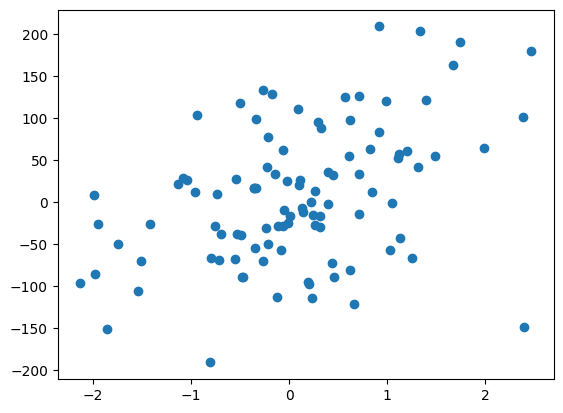

In [16]:
plt.scatter(x,y)

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
lr = LinearRegression()

In [41]:
lr.fit(x_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[32.71979417]
4.828568166742181


In [42]:
y_predict = lr.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_predict)

0.4096621553700116

In [20]:
np.mean(cross_val_score(lr,x,y,scoring='r2',cv=10))

np.float64(-0.08072914189773307)

In [35]:
class GDregressor:
    def __init__(self,learning_rate,epochs):
        self.m=100
        self.lr=learning_rate
        self.b=-120
        self.epochs=epochs

    def fit(self,x,y): 
        for i in range(self.epochs): 
            loss_slope_b=-2* np.sum(y-self.m*x.ravel()-self.b)
            loss_slope_m=-2* np.sum((y-self.m*x.ravel()-self.b)*x.ravel())
            step_size_b=loss_slope_b*self.lr
            step_size_m=loss_slope_m*self.lr
            self.b= self.b-step_size_b
            self.m= self.m-step_size_m
            # print(loss_slope,self.b)
        print(self.m, self.b)

    def predict(self,x): 
        return self.m*x+self.b

In [36]:
gd = GDregressor(0.001,50)

In [43]:
gd.fit(x_train,y_train)

32.721263683064436 4.8274834135141225


In [44]:
y_predict = gd.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_predict)

0.40967161336321456